<a href="https://colab.research.google.com/github/jessguerzoni/C111/blob/main/Cap06_P1eP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Dataset Paises

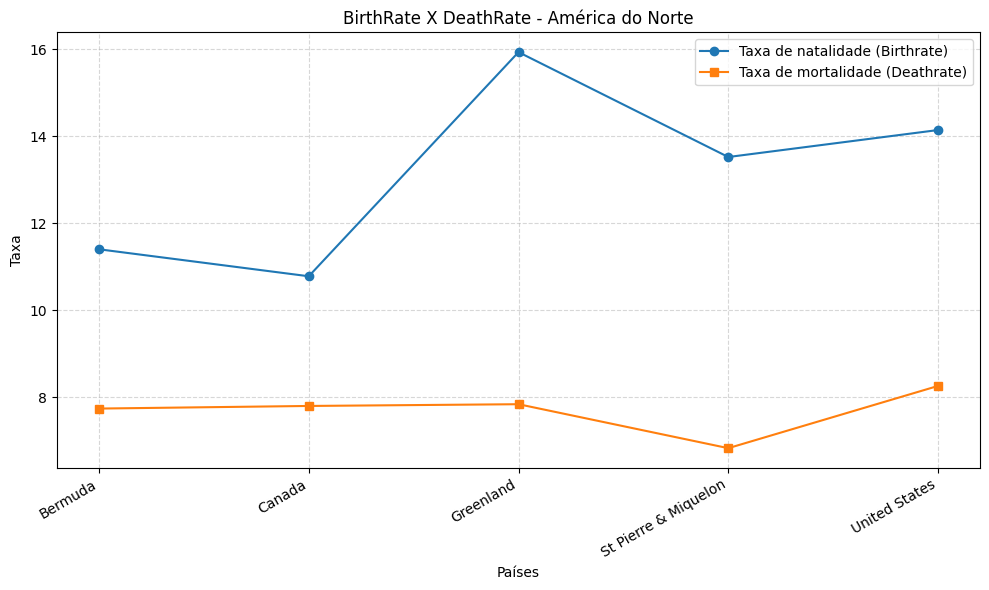

In [2]:
#Grafico de linhas

df = pd.read_csv("paises.csv", sep=";", encoding="utf-8")

#Remoção de espaço
df["Country"] = df["Country"].str.strip()
df["Region"] = df["Region"].str.strip()

#Filtro North America
america_norte = df[df["Region"] == "NORTHERN AMERICA"]

# Gráfico de linhas
plt.figure(figsize=(10, 6))
plt.plot(america_norte["Country"], america_norte["Birthrate"],
         marker="o", label="Taxa de natalidade (Birthrate)")
plt.plot(america_norte["Country"], america_norte["Deathrate"],
         marker="s", label="Taxa de mortalidade (Deathrate)")

plt.title("BirthRate X DeathRate - América do Norte")
plt.xlabel("Países")
plt.ylabel("Taxa")
plt.xticks(rotation=30, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

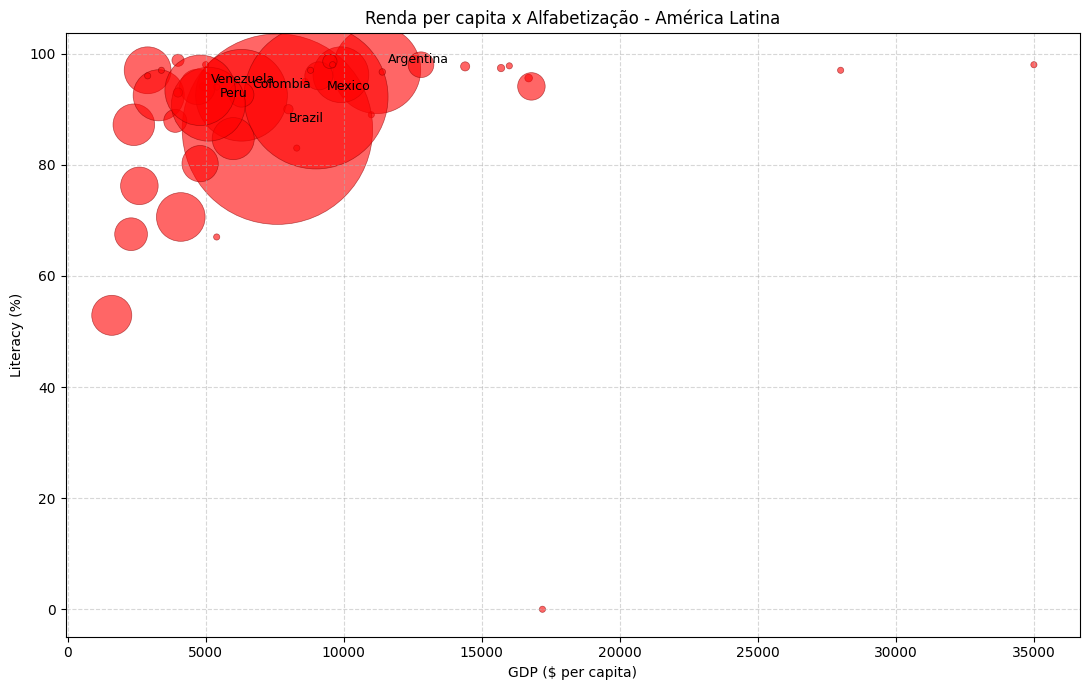

In [8]:

df = pd.read_csv("paises.csv", sep=";", encoding="utf-8")

#Tirar espaços extras
df["Country"] = df["Country"].str.strip()
df["Region"] = df["Region"].str.strip()

# Filtro da América Latina
la = df[df["Region"] == "LATIN AMER. & CARIB"]


#Tamanho
tamanho = la["Population"] / 10000
tamanho = tamanho.clip(lower=20)

plt.figure(figsize=(11, 7))
plt.scatter(
    la["GDP ($ per capita)"],
    la["Literacy (%)"],
    s=tamanho,
    alpha=0.6,
    color="red",
    edgecolors="darkred",
    linewidths=0.5,
)

#Países mais populosos
for _, linha in la.nlargest(6, "Population").iterrows():
    plt.annotate(
        linha["Country"],
        (linha["GDP ($ per capita)"], linha["Literacy (%)"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )

plt.title("Renda per Capita x Alfabetização - América Latina")
plt.xlabel("GDP ($ per capita)")
plt.ylabel("Literacy (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:

df = pd.read_csv("paises.csv", sep=";", encoding="utf-8")

#Limpar espaços
df["Country"] = df["Country"].str.strip()
df["Region"] = df["Region"].str.strip()

# Filtra a Europa Ocidental
we = df[df["Region"] == "WESTERN EUROPE"]

fig, graf1 = plt.subplots(figsize=(13, 7))

#Grafico 1
graf1.plot(
    we["Country"], we["GDP ($ per capita)"],
    color="tab:blue", marker="o", linestyle="-", linewidth=2,
    label="GDP ($ per capita)",
)
graf1.set_xlabel("País")
graf1.set_ylabel("GDP ($ per capita)", color="tab:pink")
graf1.tick_params(axis="y", labelcolor="tab:pink")
graf1.tick_params(axis="x", rotation=75)

#Grafico 2
graf2 = graf1.twinx()
graf2.plot(
    we["Country"], we["Phones (per 1000)"],
    color="tab:red", marker="s", linestyle="--", linewidth=2,
    label="Phones (per 1000)",
)
graf2.set_ylabel("Phones (per 1000)", color="tab:red")
graf2.tick_params(axis="y", labelcolor="tab:red")


linhas1, rotulos1 = graf1.get_legend_handles_labels()
linhas2, rotulos2 = graf2.get_legend_handles_labels()
graf1.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc="upper left")

plt.title("GDP per capita x Telefones por 1000 habitantes - Europa Ocidental")
graf1.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

DataSet SPACE

In [ ]:
#01
df = pd.read_csv("space.csv", sep=";", encoding="utf-8")

# Limpeza de espaços extras
df["Company Name"] = df["Company Name"].str.strip()

# Extrai o país
df["Pais"] = df["Location"].str.split().str[-1]

# Filtra EUA e China
filtrado = df[df["Pais"].isin(["USA", "China"])]

#remove repetidos
empresas = filtrado.groupby("Pais")["Company Name"].nunique()
print(empresas)

# Gráfico de barras
plt.figure(figsize=(7, 6))
barras = plt.bar(empresas.index, empresas.values, color=["tab:purple", "tab:green"])
plt.bar_label(barras)  # mostra o número em cima de cada barra

plt.title("Empresas espaciais diferentes - EUA x China")
plt.xlabel("País")
plt.ylabel("Número de empresas")
plt.tight_layout()
plt.show()

In [ ]:
#03
df = pd.read_csv("space.csv", sep=";", encoding="utf-8")
df["Company Name"] = df["Company Name"].str.strip()

# Filtra a Roscosmos
ros = df[df["Company Name"] == "Roscosmos"]

# Agrupamentos
resultado = ros["Status Mission"].apply(
    lambda s: "Sucesso" if s == "Success" else "Falha"
)
contagem = resultado.value_counts()
print(contagem)

# Gráfico de torta
plt.figure(figsize=(7, 7))
plt.pie(
    contagem.values,
    labels=contagem.index,
    autopct="%1.1f%%",
    colors=["tab:purple", "tab:red"],
    startangle=90,
)
plt.title("Missões da Roscosmos")
plt.tight_layout()
plt.show()

In [ ]:
#04
df = pd.read_csv("space.csv", sep=";", encoding="utf-8")
df["Company Name"] = df["Company Name"].str.strip()
df["Status Mission"] = df["Status Mission"].str.strip()

# Filtro com os "Failure"
falhas = df[df["Status Mission"] == "Failure"]

# As 5 empresas com mais falhas
top5 = falhas["Company Name"].value_counts().head(5)
print(top5)

# Gráfico de barras
plt.figure(figsize=(9, 6))
barras = plt.bar(top5.index, top5.values, color="tab:blue")
plt.bar_label(barras)

plt.title("Top 5 empresas com mais missões com status Failure")
plt.xlabel("Empresa")
plt.ylabel("Número de missões com falha")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
#06

df = pd.read_csv("space.csv", sep=";", encoding="utf-8")
df["Status Rocket"] = df["Status Rocket"].str.strip()

contagem = df["Status Rocket"].value_counts()
print(contagem)

plt.figure(figsize=(7, 7))
plt.pie(
    contagem.values,
    labels=contagem.index,
    autopct="%1.1f%%",
    colors=["tab:red", "tab:pink"],
    startangle=90,
)
plt.title("Status dos foguetes")
plt.tight_layout()
plt.show()

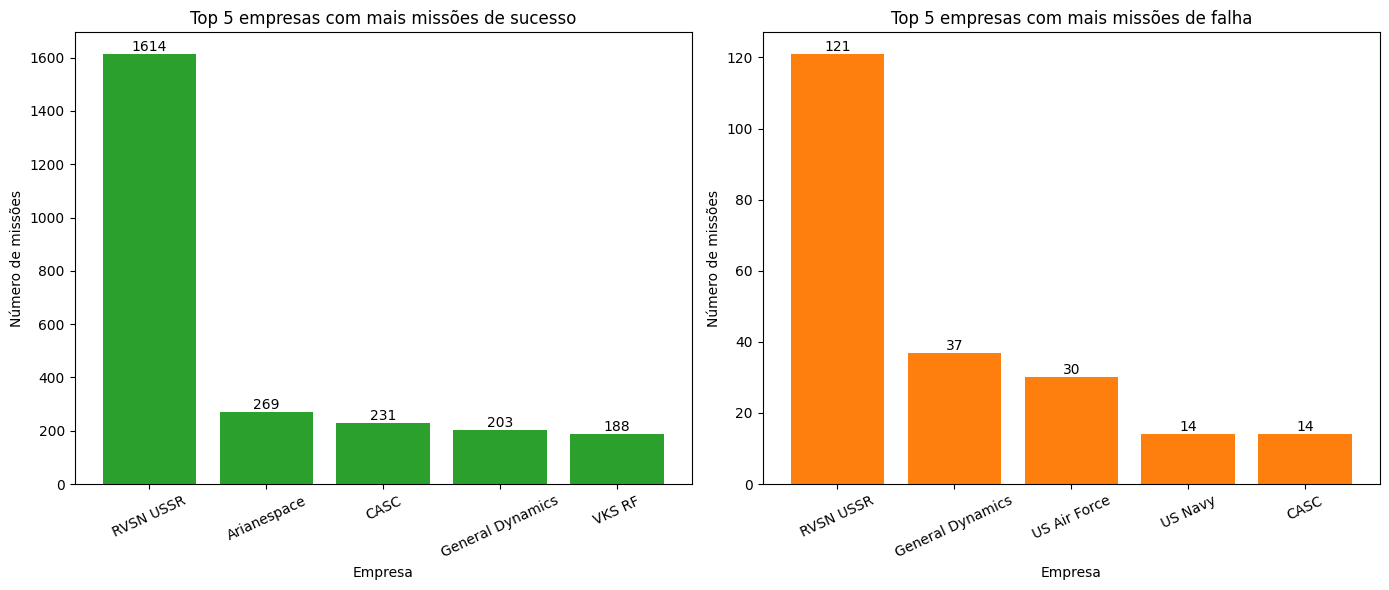

In [30]:
#08
df = pd.read_csv("space.csv", sep=";", encoding="utf-8")
df["Company Name"] = df["Company Name"].str.strip()
df["Status Mission"] = df["Status Mission"].str.strip()


top_sucesso = df[df["Status Mission"] == "Success"]["Company Name"].value_counts().head(5)
top_falha = df[df["Status Mission"] == "Failure"]["Company Name"].value_counts().head(5)

plt.figure(figsize=(14, 6))

# Gráfico sucessos
plt.subplot(1, 2, 1)
barras1 = plt.bar(top_sucesso.index, top_sucesso.values, color="tab:green")
plt.bar_label(barras1)
plt.title("Top 5 empresas com mais missões de sucesso")
plt.xlabel("Empresa")
plt.ylabel("Número de missões")
plt.xticks(rotation=25)

# Gráfico falhas
plt.subplot(1, 2, 2)
barras2 = plt.bar(top_falha.index, top_falha.values, color="tab:orange")
plt.bar_label(barras2)
plt.title("Top 5 empresas com mais missões de falha")
plt.xlabel("Empresa")
plt.ylabel("Número de missões")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()